In [2]:
%run 00setup.ipynb

✅ Setup complete


In [3]:
TRADING_DAYS = 252
ALPHA_CVAR = 0.05
TRADING_DAYS = 252
ALPHA_CVAR = 0.05

In [4]:
def annualized_return(ret: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    wealth = (1 + ret).prod()
    n_years = len(ret) / periods_per_year
    if n_years <= 0:
        return np.nan
    return wealth ** (1 / n_years) - 1

def annualized_vol(ret: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    ret = ret.dropna()
    if len(ret) < 2:
        return np.nan
    return ret.std(ddof=1) * np.sqrt(periods_per_year)

def sharpe_ratio(ret: pd.Series, rf: float = 0.0, periods_per_year: int = TRADING_DAYS) -> float:
    ret = ret.dropna()
    if len(ret) < 2:
        return np.nan
    ann_ret = annualized_return(ret, periods_per_year)
    ann_vol = annualized_vol(ret, periods_per_year)
    if ann_vol == 0 or np.isnan(ann_vol):
        return np.nan
    return (ann_ret - rf) / ann_vol

def max_drawdown(ret: pd.Series) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    return dd.min()

def cvar_from_returns(ret: pd.Series, alpha: float = ALPHA_CVAR) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    q = ret.quantile(alpha)
    tail = ret[ret <= q]
    if len(tail) == 0:
        return q
    return tail.mean()

def perf_summary(ret: pd.Series, name: str = None) -> pd.Series:
    out = pd.Series({
        "CAGR": annualized_return(ret),
        "AnnVol": annualized_vol(ret),
        "Sharpe": sharpe_ratio(ret),
        "MaxDD": max_drawdown(ret),
        "CVaR_5pct": cvar_from_returns(ret),
        "TerminalWealth": (1 + ret.dropna()).prod()
    })
    if name is not None:
        out.name = name
    return out

In [5]:
# Load actual backtest outputs using your project style
prices = load_df("prices_clean", DATA_DIR, fmt="parquet")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

px_col = "adj_close"
prices["ret_1d"] = prices.groupby("ticker")[px_col].pct_change()

R = prices.pivot(index="date", columns="ticker", values="ret_1d").sort_index()
R = R.replace([np.inf, -np.inf], np.nan).dropna(how="all")

res_eq   = load_df("bt_eq_topk", DATA_DIR, fmt="parquet")
res_vp   = load_df("bt_invvol_topk", DATA_DIR, fmt="parquet")
res_mv   = load_df("bt_mv_topk", DATA_DIR, fmt="parquet")
res_cvar = load_df("bt_cvar_topk", DATA_DIR, fmt="parquet")
res_hyb  = load_df("bt_hybrid_topk", DATA_DIR, fmt="parquet")

for df in [res_eq, res_vp, res_mv, res_cvar, res_hyb]:
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)

In [6]:
# Rebuild benchmark same way as in monte carlo notebook
bench_eq_univ = R.mean(axis=1).fillna(0.0)

def vol_target(net_ret, target_vol=0.12, lookback=63):
    vol = net_ret.rolling(lookback).std() * np.sqrt(252)
    scale = (target_vol / vol).replace([np.inf, -np.inf], np.nan).clip(0, 3.0)
    scale = scale.shift(1).fillna(0.0)
    return net_ret * scale, scale

bench_eq_univ_vt, _ = vol_target(bench_eq_univ, target_vol=0.12, lookback=63)

strat_ret = pd.DataFrame({
    "EQ": res_eq["vt"],
    "INVVOL": res_vp["vt"],
    "MV": res_mv["vt"],
    "CVaR": res_cvar["vt"],
    "HYBRID": res_hyb["vt"],
    "BENCHMARK": bench_eq_univ_vt
}).sort_index()

STRATEGY_COLS = ["EQ", "INVVOL", "MV", "CVaR", "HYBRID"]
BENCH_COL = "BENCHMARK"
plot_cols = STRATEGY_COLS + [BENCH_COL]

In [7]:
# Align from true live start
live_mask = strat_ret[STRATEGY_COLS].abs().sum(axis=1) > 1e-12
common_start = strat_ret.index[live_mask][0]

strat_ret = strat_ret.loc[common_start:, plot_cols].dropna().copy()

print("Stress test sample:", strat_ret.index.min().date(), "->", strat_ret.index.max().date())
display(strat_ret.head())

Stress test sample: 2016-06-02 -> 2025-12-30


,EQ,INVVOL,MV,CVaR,HYBRID,BENCHMARK
date,,,,,,
2016-06-02,0.015767,0.014106,0.015001,0.012391,0.014479,0.003904
2016-06-03,0.002510,-0.000466,-0.003163,-0.010037,-0.004538,0.008526
2016-06-06,0.023497,0.021973,0.022542,0.020110,0.022056,0.003846
2016-06-07,0.007902,0.005932,0.005394,0.001583,0.004632,0.004473
2016-06-08,0.015114,0.013899,0.014372,0.012439,0.013985,0.008370


In [8]:
# 1) Historical stress periods
# Keep it simple and intuitive

stress_periods = {
    "2018_Q4_Selloff": ("2018-10-01", "2018-12-31"),
    "2020_COVID_Crash": ("2020-02-15", "2020-04-30"),
    "2022_Rate_Shock": ("2022-01-01", "2022-12-31"),
}

In [9]:
hist_stress_rows = []

for label, (start, end) in stress_periods.items():
    sub = strat_ret.loc[start:end].copy()
    if len(sub) == 0:
        continue

    for c in plot_cols:
        s = perf_summary(sub[c], name=c).to_dict()
        s["StressPeriod"] = label
        s["Start"] = pd.to_datetime(start)
        s["End"] = pd.to_datetime(end)
        s["Portfolio"] = c
        hist_stress_rows.append(s)

hist_stress_df = pd.DataFrame(hist_stress_rows)
display(hist_stress_df.head())

save_df(hist_stress_df, "stress_test_historical_periods", DATA_DIR, fmt="parquet")

,CAGR,AnnVol,Sharpe,MaxDD,CVaR_5pct,TerminalWealth,StressPeriod,Start,End,Portfolio
0,-0.268287,0.109137,-2.458270,-0.088195,-0.017386,0.924880,2018_Q4_Selloff,2018-10-01,2018-12-31,EQ
1,-0.233630,0.108805,-2.147227,-0.078956,-0.018192,0.935642,2018_Q4_Selloff,2018-10-01,2018-12-31,INVVOL
2,-0.328781,0.114569,-2.869720,-0.109523,-0.017569,0.905141,2018_Q4_Selloff,2018-10-01,2018-12-31,MV
3,-0.263327,0.110185,-2.389858,-0.087656,-0.016757,0.926443,2018_Q4_Selloff,2018-10-01,2018-12-31,CVaR
4,-0.315894,0.113403,-2.785589,-0.105159,-0.017248,0.909454,2018_Q4_Selloff,2018-10-01,2018-12-31,HYBRID


In [10]:
hist_stress_pivot = hist_stress_df.pivot_table(
    index=["StressPeriod", "Portfolio"],
    values=["CAGR", "AnnVol", "Sharpe", "MaxDD", "CVaR_5pct", "TerminalWealth"],
    aggfunc="first"
).reset_index()

display(hist_stress_pivot.round(4))

,StressPeriod,Portfolio,AnnVol,CAGR,CVaR_5pct,MaxDD,Sharpe,TerminalWealth
0,2018_Q4_Selloff,BENCHMARK,0.1836,-0.4157,-0.0260,-0.1564,-2.2635,0.8743
1,2018_Q4_Selloff,CVaR,0.1102,-0.2633,-0.0168,-0.0877,-2.3899,0.9264
2,2018_Q4_Selloff,EQ,0.1091,-0.2683,-0.0174,-0.0882,-2.4583,0.9249
3,2018_Q4_Selloff,HYBRID,0.1134,-0.3159,-0.0172,-0.1052,-2.7856,0.9095
4,2018_Q4_Selloff,INVVOL,0.1088,-0.2336,-0.0182,-0.0790,-2.1472,0.9356
5,2018_Q4_Selloff,MV,0.1146,-0.3288,-0.0176,-0.1095,-2.8697,0.9051
6,2020_COVID_Crash,BENCHMARK,0.2865,-0.6085,-0.0473,-0.2267,-2.1239,0.8240
7,2020_COVID_Crash,CVaR,0.2166,-0.2561,-0.0323,-0.1301,-1.1824,0.9408
8,2020_COVID_Crash,EQ,0.2190,-0.2112,-0.0306,-0.1201,-0.9646,0.9522
9,2020_COVID_Crash,HYBRID,0.2120,-0.3026,-0.0313,-0.1377,-1.4277,0.9283


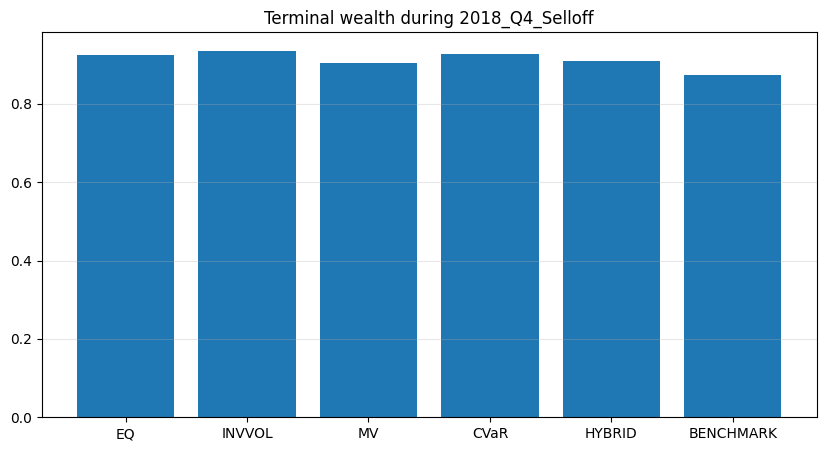

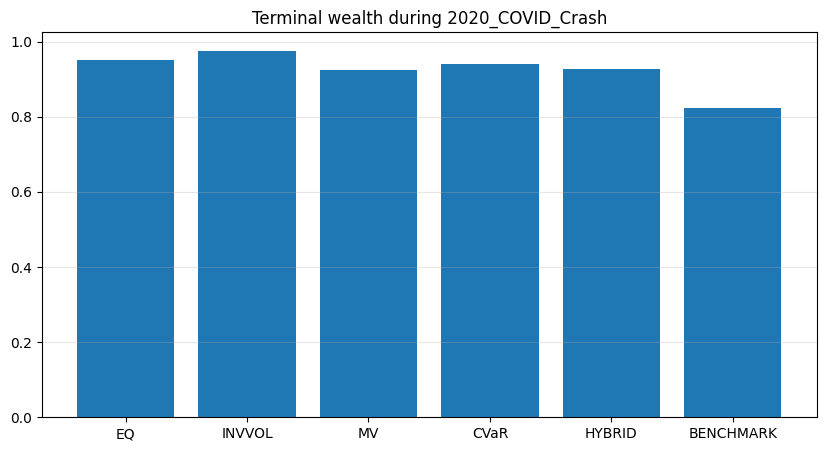

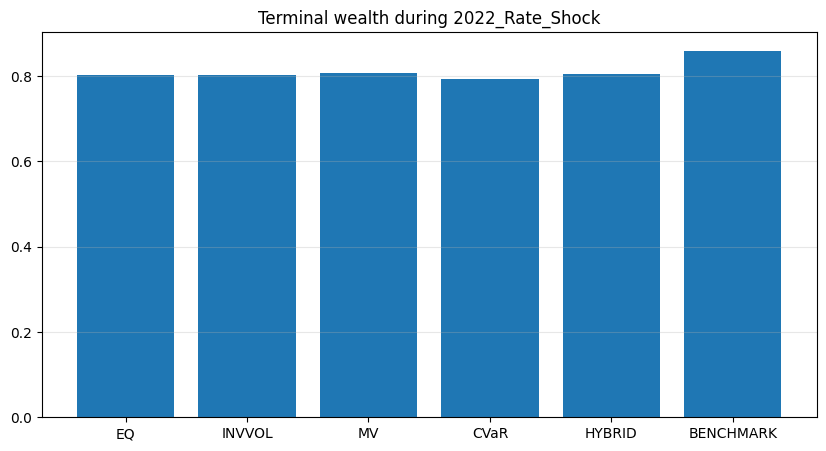

In [11]:
# One clean plot: terminal wealth by stress period

for label in hist_stress_df["StressPeriod"].unique():
    sub = hist_stress_df[hist_stress_df["StressPeriod"] == label].copy()

    plt.figure(figsize=(10, 5))
    plt.bar(sub["Portfolio"], sub["TerminalWealth"])
    plt.title(f"Terminal wealth during {label}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

In [12]:
# 2) Simple one-day shock scenarios on asset returns
# Keep this static and simple. No re-optimization.

common_idx = strat_ret.index.intersection(R.index)
R_sub = R.loc[common_idx].dropna(how="any").copy()

assets = R_sub.columns.tolist()
N = len(assets)

w_eq = np.ones(N) / N

cov_hat = R_sub.cov().values * 252
eps = 1e-4
cov_hat_stable = cov_hat + eps * np.eye(cov_hat.shape[0])

invvol = 1 / np.sqrt(np.clip(np.diag(cov_hat_stable), 1e-12, None))
w_iv = invvol / invvol.sum()

ref_weights = {
    "EQ": pd.Series(w_eq, index=assets),
    "INVVOL": pd.Series(w_iv, index=assets),
}

In [13]:
# Define simple shocks by asset group
# Edit tickers if needed, but this should fit your expanded ETF universe

equity_like = ["SPY", "QQQ", "DIA", "IWM", "FEZ", "EWU", "EWJ", "EEM", "USMV", "VNQ", "VTV", "VUG", "XLP", "XLU"]
bond_like   = ["TLT", "IEF", "LQD", "SHY"]
gold_like   = ["GLD"]
commodity_like = ["DBC"]

shock_scenarios = {
    "Equity_-5pct": {t: -0.05 for t in equity_like},
    "Bond_-3pct": {t: -0.03 for t in bond_like},
    "Gold_-4pct": {t: -0.04 for t in gold_like},
    "Commodity_-5pct": {t: -0.05 for t in commodity_like},
    "Equity_-5pct_Bond_-2pct": {**{t: -0.05 for t in equity_like}, **{t: -0.02 for t in bond_like}},
}

In [14]:
shock_rows = []

for scen_name, shock_map in shock_scenarios.items():
    shock_vec = pd.Series(0.0, index=assets)
    for k, v in shock_map.items():
        if k in shock_vec.index:
            shock_vec.loc[k] = v

    for pname, w in ref_weights.items():
        port_shock = float((w * shock_vec).sum())
        shock_rows.append({
            "Scenario": scen_name,
            "Portfolio": pname,
            "ShockReturn": port_shock
        })

shock_df = pd.DataFrame(shock_rows)
display(shock_df.round(4))

save_df(shock_df, "stress_test_shock_scenarios", DATA_DIR, fmt="parquet")

,Scenario,Portfolio,ShockReturn
0,Equity_-5pct,EQ,-0.0350
1,Equity_-5pct,INVVOL,-0.0216
2,Bond_-3pct,EQ,-0.0060
3,Bond_-3pct,INVVOL,-0.0149
4,Gold_-4pct,EQ,-0.0020
5,Gold_-4pct,INVVOL,-0.0016
6,Commodity_-5pct,EQ,-0.0025
7,Commodity_-5pct,INVVOL,-0.0016
8,Equity_-5pct_Bond_-2pct,EQ,-0.0390
9,Equity_-5pct_Bond_-2pct,INVVOL,-0.0315


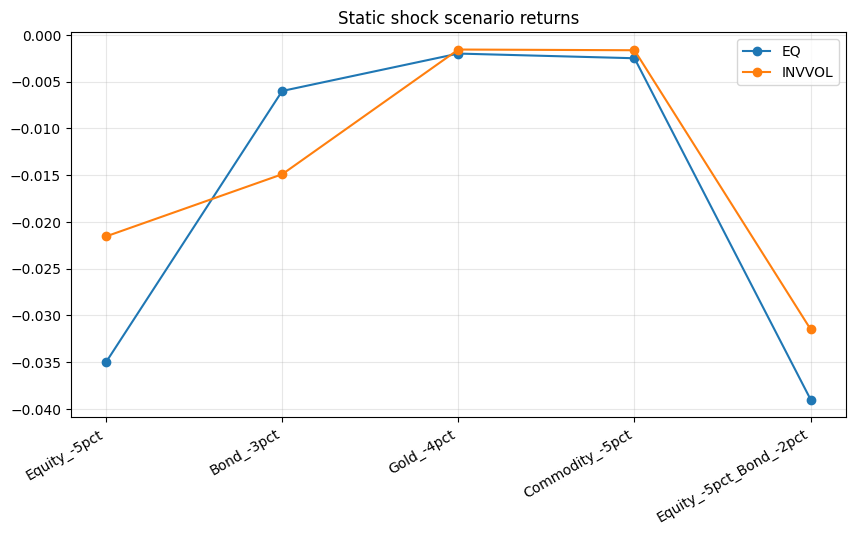

In [15]:
plt.figure(figsize=(10, 5))
for pname in shock_df["Portfolio"].unique():
    sub = shock_df[shock_df["Portfolio"] == pname]
    plt.plot(sub["Scenario"], sub["ShockReturn"], marker="o", label=pname)

plt.xticks(rotation=30, ha="right")
plt.title("Static shock scenario returns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
# Final compact tables for report
display(hist_stress_pivot.round(4))
display(shock_df.round(4))

,StressPeriod,Portfolio,AnnVol,CAGR,CVaR_5pct,MaxDD,Sharpe,TerminalWealth
0,2018_Q4_Selloff,BENCHMARK,0.1836,-0.4157,-0.0260,-0.1564,-2.2635,0.8743
1,2018_Q4_Selloff,CVaR,0.1102,-0.2633,-0.0168,-0.0877,-2.3899,0.9264
2,2018_Q4_Selloff,EQ,0.1091,-0.2683,-0.0174,-0.0882,-2.4583,0.9249
3,2018_Q4_Selloff,HYBRID,0.1134,-0.3159,-0.0172,-0.1052,-2.7856,0.9095
4,2018_Q4_Selloff,INVVOL,0.1088,-0.2336,-0.0182,-0.0790,-2.1472,0.9356
5,2018_Q4_Selloff,MV,0.1146,-0.3288,-0.0176,-0.1095,-2.8697,0.9051
6,2020_COVID_Crash,BENCHMARK,0.2865,-0.6085,-0.0473,-0.2267,-2.1239,0.8240
7,2020_COVID_Crash,CVaR,0.2166,-0.2561,-0.0323,-0.1301,-1.1824,0.9408
8,2020_COVID_Crash,EQ,0.2190,-0.2112,-0.0306,-0.1201,-0.9646,0.9522
9,2020_COVID_Crash,HYBRID,0.2120,-0.3026,-0.0313,-0.1377,-1.4277,0.9283


,Scenario,Portfolio,ShockReturn
0,Equity_-5pct,EQ,-0.0350
1,Equity_-5pct,INVVOL,-0.0216
2,Bond_-3pct,EQ,-0.0060
3,Bond_-3pct,INVVOL,-0.0149
4,Gold_-4pct,EQ,-0.0020
5,Gold_-4pct,INVVOL,-0.0016
6,Commodity_-5pct,EQ,-0.0025
7,Commodity_-5pct,INVVOL,-0.0016
8,Equity_-5pct_Bond_-2pct,EQ,-0.0390
9,Equity_-5pct_Bond_-2pct,INVVOL,-0.0315
